In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/resize/val"

image_dir = os.path.join(DATASET_PATH, "images")
mask_dir = os.path.join(DATASET_PATH, "masks")

print("Images:", len(os.listdir(image_dir)))
print("Masks :", len(os.listdir(mask_dir)))


Images: 1544
Masks : 1544


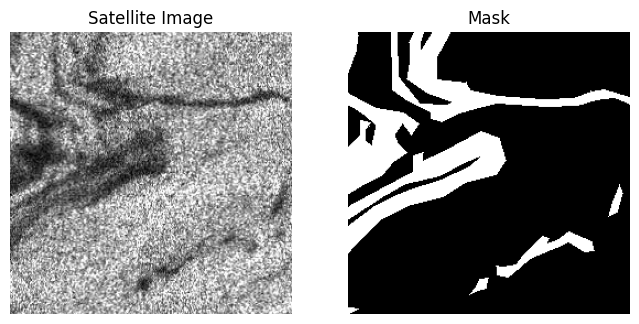

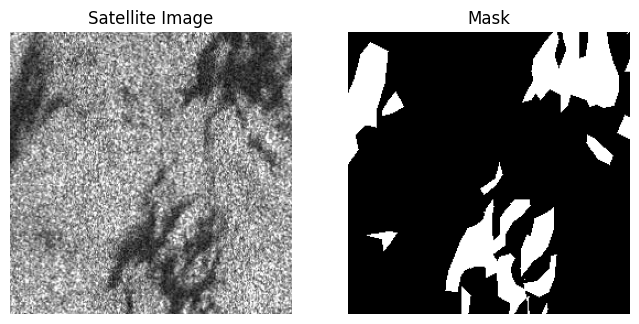

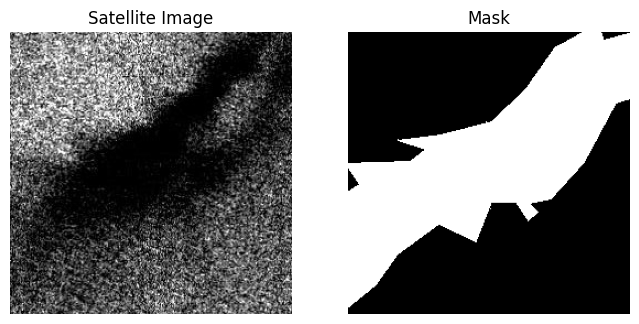

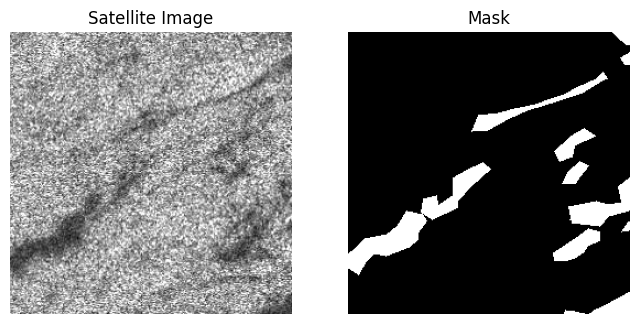

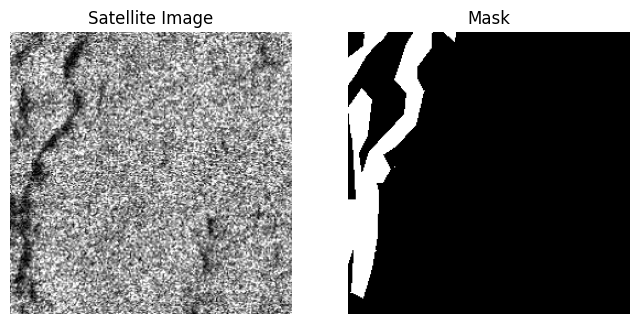

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_files = sorted(os.listdir(image_dir))[:5]
mask_files = sorted(os.listdir(mask_dir))[:5]

for i in range(5):
    img = cv2.imread(os.path.join(image_dir, image_files[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, mask_files[i]), 0)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Satellite Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.show()


In [ ]:
img = cv2.imread(os.path.join(image_dir, image_files[0]))
mask = cv2.imread(os.path.join(mask_dir, mask_files[0]), 0)

print("Image Shape:", img.shape)
print("Mask Shape :", mask.shape)


Image Shape: (256, 256, 3)
Mask Shape : (256, 256)


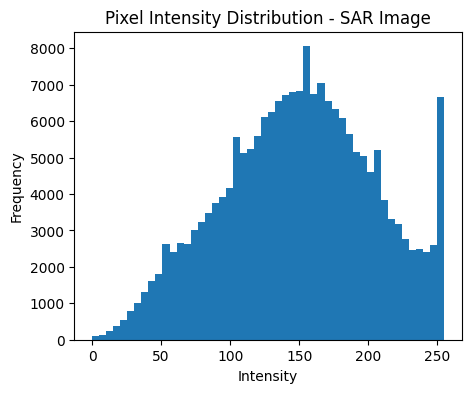

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(img.ravel(), bins=50)
plt.title("Pixel Intensity Distribution - SAR Image")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()


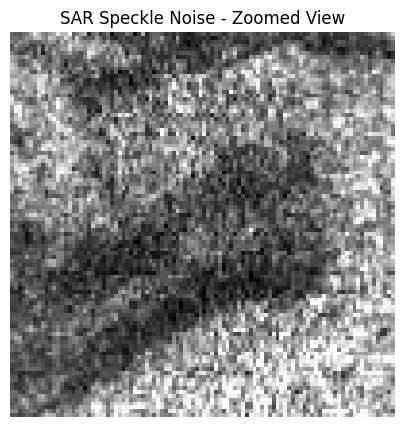

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(img[60:160, 60:160])
plt.title("SAR Speckle Noise - Zoomed View")
plt.axis('off')
plt.show()


In [ ]:
!cp -r "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring" "/content/oil_spill_dataset"


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

base_dir = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"
splits = ["train","val"]

valid_exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")

overall_oil = 0
overall_no_oil = 0

for split in splits:
    split_dir = os.path.join(base_dir, split)
    images_dir = os.path.join(split_dir, "images")
    masks_dir  = os.path.join(split_dir, "masks")

    if not os.path.isdir(images_dir) or not os.path.isdir(masks_dir):
        print(f"\n Skipping {split}: images/ or masks/ folder not found")
        continue

    files = [f for f in os.listdir(images_dir) if f.lower().endswith(valid_exts)]
    oil_count = 0
    no_oil_count = 0

    print(f"\nProcessing {split} ({len(files)} images)...")

    for file in tqdm(files):
        mask_path = os.path.join(masks_dir, file)
        if not os.path.exists(mask_path):
            continue

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        if cv2.countNonZero(mask) > 0:
            oil_count += 1
        else:
            no_oil_count += 1

    overall_oil += oil_count
    overall_no_oil += no_oil_count

print("\n===== OVERALL=====")
print(f"Total oil spill images   : {overall_oil}")
print(f"Total non-oil images     : {overall_no_oil}")
print(f"Grand total images       : {overall_oil + overall_no_oil}")



Processing train (4873 images)...


100%|██████████| 4873/4873 [20:33<00:00,  3.95it/s]



Processing val (1542 images)...


100%|██████████| 1542/1542 [06:24<00:00,  4.01it/s]


===== OVERALL=====
Total oil spill images   : 6160
Total non-oil images     : 255
Grand total images       : 6415


#Pre-Processing :

In [ ]:
import os
import cv2
from tqdm import tqdm


BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"
TARGET_SIZE = (256, 256)

INPUT_SPLITS = {
    "test": "train",
    "val": "val"
}

OUTPUT_BASE = os.path.join(BASE_PATH, "resize")

for src_split, dst_split in INPUT_SPLITS.items():
    print(f"\n🔄 Resizing {src_split} → resize/{dst_split}")

    src_img = os.path.join(BASE_PATH, src_split, "images")
    src_mask = os.path.join(BASE_PATH, src_split, "masks")

    dst_img = os.path.join(OUTPUT_BASE, dst_split, "images")
    dst_mask = os.path.join(OUTPUT_BASE, dst_split, "masks")

    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_mask, exist_ok=True)

    for fname in tqdm(os.listdir(src_img)):
        img_path = os.path.join(src_img, fname)
        mask_path = os.path.join(src_mask, fname)

        if not os.path.exists(mask_path):
            continue

        image = cv2.imread(img_path)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            continue

        image_resized = cv2.resize(image, TARGET_SIZE, cv2.INTER_LINEAR)
        mask_resized  = cv2.resize(mask, TARGET_SIZE, cv2.INTER_NEAREST)


        cv2.imwrite(os.path.join(dst_img, fname), image_resized)
        cv2.imwrite(os.path.join(dst_mask, fname), mask_resized)

print("\n✅ Resize step completed. Files saved in pre_processed/")



🔄 Resizing train → resize/train


100%|██████████| 4873/4873 [26:43<00:00,  3.04it/s]



🔄 Resizing val → resize/val


100%|██████████| 1542/1542 [08:41<00:00,  2.96it/s]


✅ Resize step completed. Files saved in pre_processed/


In [ ]:
import os
import cv2
from tqdm import tqdm


BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"
TARGET_SIZE = (256, 256)

INPUT_SPLITS = {
    "test": "test"
}

OUTPUT_BASE = os.path.join(BASE_PATH, "resize")

for src_split, dst_split in INPUT_SPLITS.items():
    print(f"\n🔄 Resizing {src_split} → resize/{dst_split}")

    src_img = os.path.join(BASE_PATH, src_split, "images")
    src_mask = os.path.join(BASE_PATH, src_split, "masks")

    dst_img = os.path.join(OUTPUT_BASE, dst_split, "images")
    dst_mask = os.path.join(OUTPUT_BASE, dst_split, "masks")

    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_mask, exist_ok=True)

    for fname in tqdm(os.listdir(src_img)):
        img_path = os.path.join(src_img, fname)
        mask_path = os.path.join(src_mask, fname)

        if not os.path.exists(mask_path):
            continue

        image = cv2.imread(img_path)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            continue

        image_resized = cv2.resize(image, TARGET_SIZE, cv2.INTER_LINEAR)
        mask_resized  = cv2.resize(mask, TARGET_SIZE, cv2.INTER_NEAREST)


        cv2.imwrite(os.path.join(dst_img, fname), image_resized)
        cv2.imwrite(os.path.join(dst_mask, fname), mask_resized)

print("\n✅ Resize step completed. Files saved in resize/")



🔄 Resizing test → resize/test


100%|██████████| 787/787 [07:21<00:00,  1.78it/s]


✅ Resize step completed. Files saved in pre_processed/


sentinel_1887.png | shape=(256, 256)
sentinel_1852.png | shape=(256, 256)
palsar_950.png | shape=(256, 256)
palsar_1631.png | shape=(256, 256)
sentinel_744.png | shape=(256, 256)


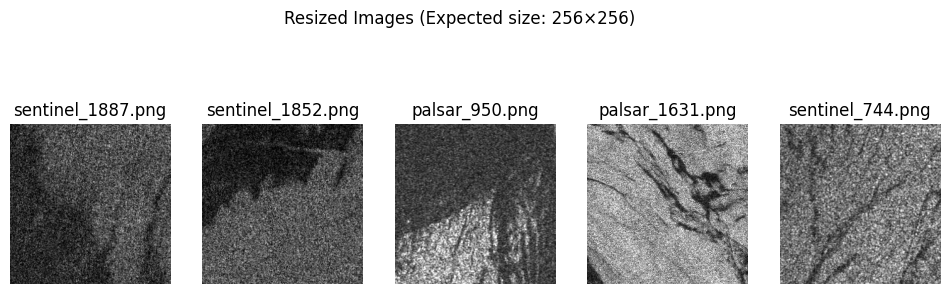

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

resize_dir = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/resize/train/images"

files = [f for f in os.listdir(resize_dir)
         if f.lower().endswith((".png", ".jpg", ".jpeg"))][:5]

plt.figure(figsize=(12, 4))

for i, fname in enumerate(files):
    img = cv2.imread(os.path.join(resize_dir, fname), cv2.IMREAD_GRAYSCALE)

    print(f"{fname} | shape={img.shape}")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(fname)
    plt.axis("off")

plt.suptitle("Resized Images (Expected size: 256×256)")
plt.show()


sentinel_2416.png | shape=(256, 256)
sentinel_1686.png | shape=(256, 256)
palsar_2254.png | shape=(256, 256)
palsar_95.png | shape=(256, 256)
palsar_2297.png | shape=(256, 256)


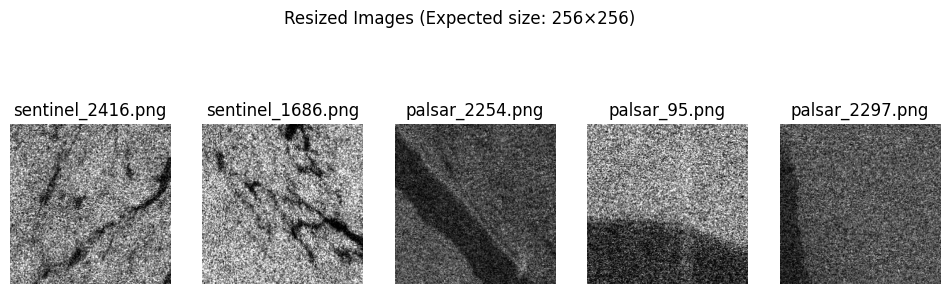

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

resize_dir = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/resize/test/images"

files = [f for f in os.listdir(resize_dir)
         if f.lower().endswith((".png", ".jpg", ".jpeg"))][:5]

plt.figure(figsize=(12, 4))

for i, fname in enumerate(files):
    img = cv2.imread(os.path.join(resize_dir, fname), cv2.IMREAD_GRAYSCALE)

    print(f"{fname} | shape={img.shape}")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(fname)
    plt.axis("off")

plt.suptitle("Resized Images (Expected size: 256×256)")
plt.show()


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

INPUT_BASE = os.path.join(BASE_PATH, "resize")
OUTPUT_BASE = os.path.join(BASE_PATH, "normalize")

SPLITS = ["train", "val"]

for split in SPLITS:
    print(f"\n🔄 Normalizing {split} images")

    src_img_dir = os.path.join(INPUT_BASE, split, "images")
    dst_img_dir = os.path.join(OUTPUT_BASE, split, "images")

    os.makedirs(dst_img_dir, exist_ok=True)

    for fname in tqdm(os.listdir(src_img_dir)):
        if not fname.lower().endswith(".png"):
            continue

        img_path = os.path.join(src_img_dir, fname)
        image = cv2.imread(img_path)

        if image is None:
            continue

        image_norm = image.astype("float32") / 255.0

        np.save(
            os.path.join(dst_img_dir, fname.replace(".png", ".npy")),
            image_norm
        )

print("\n✅ Normalization completed successfully")
print("📁 Files saved in normalize/train/images and normalize/val/images")



🔄 Normalizing train images


100%|██████████| 4873/4873 [02:36<00:00, 31.05it/s]



🔄 Normalizing val images


100%|██████████| 1542/1542 [00:47<00:00, 32.63it/s]


✅ Normalization completed successfully
📁 Files saved in normalize/train/images and normalize/val/images


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

INPUT_BASE = os.path.join(BASE_PATH, "resize")
OUTPUT_BASE = os.path.join(BASE_PATH, "normalize")

SPLITS = ["test"]

for split in SPLITS:
    print(f"\n🔄 Normalizing {split} images")

    src_img_dir = os.path.join(INPUT_BASE, split, "images")
    dst_img_dir = os.path.join(OUTPUT_BASE, split, "images")

    os.makedirs(dst_img_dir, exist_ok=True)

    for fname in tqdm(os.listdir(src_img_dir)):
        if not fname.lower().endswith(".png"):
            continue

        img_path = os.path.join(src_img_dir, fname)
        image = cv2.imread(img_path)

        if image is None:
            continue

        image_norm = image.astype("float32") / 255.0

        np.save(
            os.path.join(dst_img_dir, fname.replace(".png", ".npy")),
            image_norm
        )

print("\n✅ Normalization completed successfully")
print("📁 Files saved in normalize/train/images and normalize/val/images")



🔄 Normalizing test images


100%|██████████| 787/787 [00:34<00:00, 23.04it/s]


✅ Normalization completed successfully
📁 Files saved in normalize/train/images and normalize/val/images


sentinel_1156.npy | min=0.0000, max=1.0000
palsar_399.npy | min=0.0000, max=1.0000
palsar_1162.npy | min=0.0000, max=1.0000
palsar_2104.npy | min=0.0000, max=1.0000
palsar_2383.npy | min=0.0000, max=0.9922


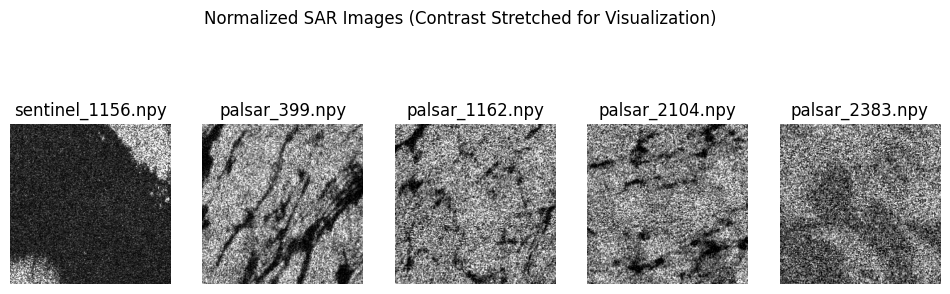

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

norm_dir = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/normalize/train/images"

files = [f for f in os.listdir(norm_dir) if f.endswith(".npy")][:5]

plt.figure(figsize=(12, 4))

for i, fname in enumerate(files):
    img = np.load(os.path.join(norm_dir, fname))

    if img.ndim == 3 and img.shape[-1] == 1:
        img = img.squeeze()


    p2, p98 = np.percentile(img, (2, 98))
    img_vis = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

    print(f"{fname} | min={img.min():.4f}, max={img.max():.4f}")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_vis, cmap="gray")
    plt.title(fname)
    plt.axis("off")

plt.suptitle("Normalized SAR Images")
plt.show()


sentinel_2416.npy | min=0.0000, max=1.0000
sentinel_1686.npy | min=0.0000, max=1.0000
palsar_2254.npy | min=0.0000, max=0.9882
palsar_95.npy | min=0.0000, max=1.0000
palsar_2297.npy | min=0.0000, max=1.0000


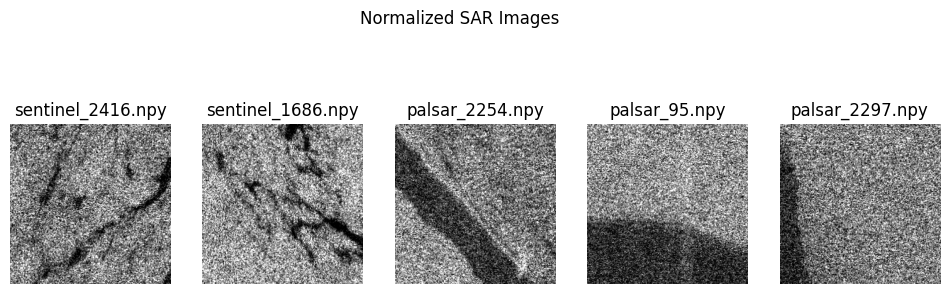

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

norm_dir = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/normalize/test/images"

files = [f for f in os.listdir(norm_dir) if f.endswith(".npy")][:5]

plt.figure(figsize=(12, 4))

for i, fname in enumerate(files):
    img = np.load(os.path.join(norm_dir, fname))

    if img.ndim == 3 and img.shape[-1] == 1:
        img = img.squeeze()


    p2, p98 = np.percentile(img, (2, 98))
    img_vis = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

    print(f"{fname} | min={img.min():.4f}, max={img.max():.4f}")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_vis, cmap="gray")
    plt.title(fname)
    plt.axis("off")

plt.suptitle("Normalized SAR Images")
plt.show()


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

INPUT_BASE = os.path.join(BASE_PATH, "normalize")
OUTPUT_BASE = os.path.join(BASE_PATH, "denoised")

SPLITS = ["train", "val"]

def strong_sar_denoise(img):
    """
    Strong SAR speckle noise reduction
    Input : normalized image [0,1]
    Output: denoised image [0,1]
    """

    # Convert to grayscale if it's a 3-channel image with identical channels
    # This ensures cv2.medianBlur and cv2.fastNlMeansDenoising get appropriate input
    if img.ndim == 3 and img.shape[-1] == 3:
        # Check if all channels are approximately equal (grayscale)
        if np.allclose(img[..., 0], img[..., 1]) and np.allclose(img[..., 0], img[..., 2]):
            img = img[..., 0] # Take one channel as grayscale

    img_uint8 = (img * 255).astype("uint8")

    # Apply median blur
    img_med = cv2.medianBlur(img_uint8, 3)

    # Apply NLM denoising based on image channels
    if img.ndim == 2: # Grayscale image (H, W)
        denoised = cv2.fastNlMeansDenoising(
            img_med,
            None,
            h=20,
            templateWindowSize=7,
            searchWindowSize=21
        )
    else: # Color image (H, W, 3)
        denoised = cv2.fastNlMeansDenoisingColored(
            img_med,
            None,
            h=20,
            hColor=20,
            templateWindowSize=7,
            searchWindowSize=21
        )

    return denoised.astype("float32") / 255.0

for split in SPLITS:
    print(f"\n🔄 Denoising {split} images")

    src_dir = os.path.join(INPUT_BASE, split, "images")
    dst_dir = os.path.join(OUTPUT_BASE, split, "images")

    os.makedirs(dst_dir, exist_ok=True)

    for fname in tqdm(os.listdir(src_dir)):
        if not fname.endswith(".npy"):
            continue

        img_path = os.path.join(src_dir, fname)
        image = np.load(img_path)

        denoised_img = strong_sar_denoise(image)

        np.save(os.path.join(dst_dir, fname), denoised_img)

print("\n✅ Strong SAR denoising completed successfully")
print("📁 Output saved in denoised/train/images and denoised/val/images")


🔄 Denoising train images


100%|██████████| 4873/4873 [21:44<00:00,  3.74it/s]



🔄 Denoising val images


100%|██████████| 1542/1542 [06:51<00:00,  3.75it/s]


✅ Strong SAR denoising completed successfully
📁 Output saved in denoised/train/images and denoised/val/images


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

INPUT_BASE = os.path.join(BASE_PATH, "normalize")
OUTPUT_BASE = os.path.join(BASE_PATH, "denoised")

SPLITS = ["test"]

def strong_sar_denoise(img):
    """
    Strong SAR speckle noise reduction
    Input : normalized image [0,1]
    Output: denoised image [0,1]
    """

    # Convert to grayscale if it's a 3-channel image with identical channels
    # This ensures cv2.medianBlur and cv2.fastNlMeansDenoising get appropriate input
    if img.ndim == 3 and img.shape[-1] == 3:
        # Check if all channels are approximately equal (grayscale)
        if np.allclose(img[..., 0], img[..., 1]) and np.allclose(img[..., 0], img[..., 2]):
            img = img[..., 0] # Take one channel as grayscale

    img_uint8 = (img * 255).astype("uint8")

    # Apply median blur
    img_med = cv2.medianBlur(img_uint8, 3)

    # Apply NLM denoising based on image channels
    if img.ndim == 2: # Grayscale image (H, W)
        denoised = cv2.fastNlMeansDenoising(
            img_med,
            None,
            h=20,
            templateWindowSize=7,
            searchWindowSize=21
        )
    else: # Color image (H, W, 3)
        denoised = cv2.fastNlMeansDenoisingColored(
            img_med,
            None,
            h=20,
            hColor=20,
            templateWindowSize=7,
            searchWindowSize=21
        )

    return denoised.astype("float32") / 255.0

for split in SPLITS:
    print(f"\n🔄 Denoising {split} images")

    src_dir = os.path.join(INPUT_BASE, split, "images")
    dst_dir = os.path.join(OUTPUT_BASE, split, "images")

    os.makedirs(dst_dir, exist_ok=True)

    for fname in tqdm(os.listdir(src_dir)):
        if not fname.endswith(".npy"):
            continue

        img_path = os.path.join(src_dir, fname)
        image = np.load(img_path)

        denoised_img = strong_sar_denoise(image)

        np.save(os.path.join(dst_dir, fname), denoised_img)

print("\n✅ Strong SAR denoising completed successfully")
print("📁 Output saved in denoised/train/images and denoised/val/images")


🔄 Denoising test images


100%|██████████| 787/787 [05:15<00:00,  2.50it/s]


✅ Strong SAR denoising completed successfully
📁 Output saved in denoised/train/images and denoised/val/images


Displaying original (normalized) vs. denoised images :


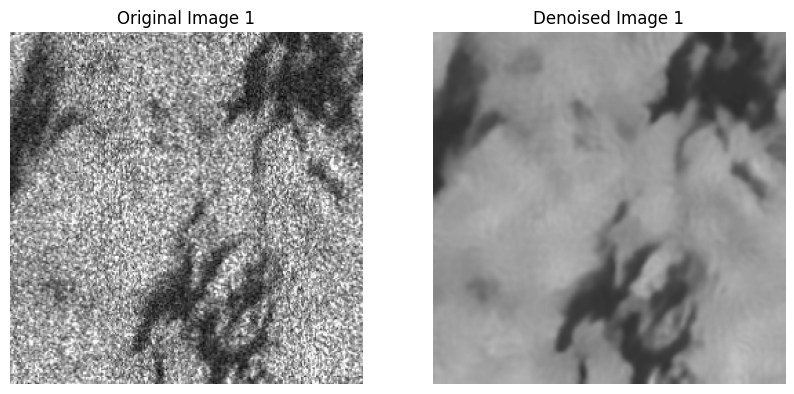

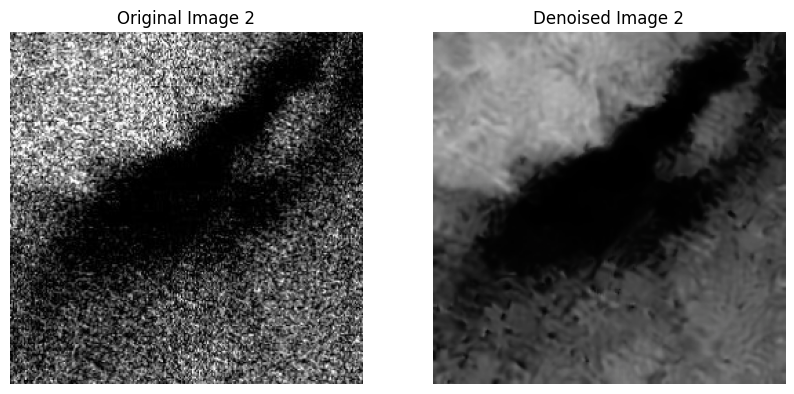

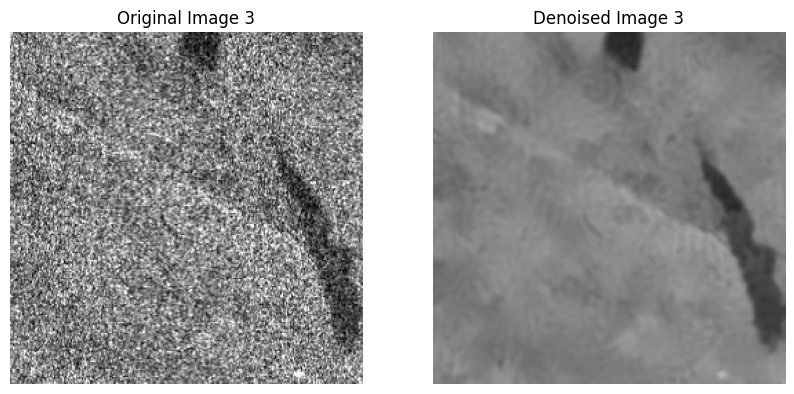

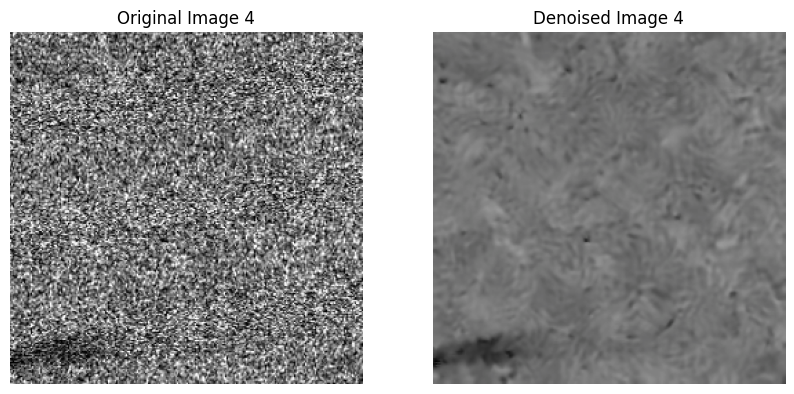

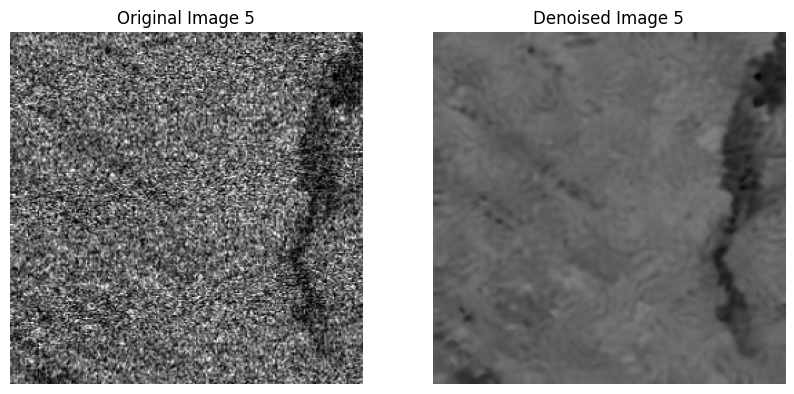

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

NORMALIZED_DIR = os.path.join(BASE_PATH, "normalize", "train", "images")
DENOISED_DIR = os.path.join(BASE_PATH, "dataset", "train", "images")


image_files = sorted([f for f in os.listdir(NORMALIZED_DIR) if f.endswith(".npy")])

print("Displaying original (normalized) vs. denoised images :")

for i in range(min(5, len(image_files))):
    fname = image_files[i]

    original_img_path = os.path.join(NORMALIZED_DIR, fname)
    original_img = np.load(original_img_path)

    denoised_img_path = os.path.join(DENOISED_DIR, fname)
    denoised_img = np.load(denoised_img_path)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray') # Added cmap='gray'
    plt.title(f"Original Image {i+1}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(denoised_img, cmap='gray') # Added cmap='gray'
    plt.title(f"Denoised Image {i+1}")
    plt.axis('off')

    plt.show()

Displaying Test original (normalized) vs. denoised images :


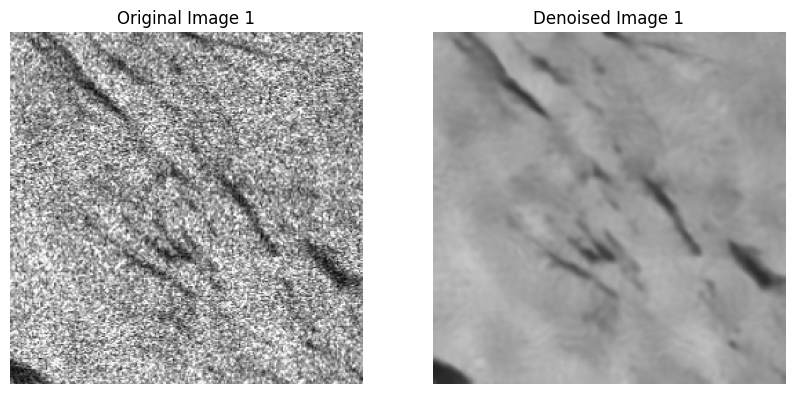

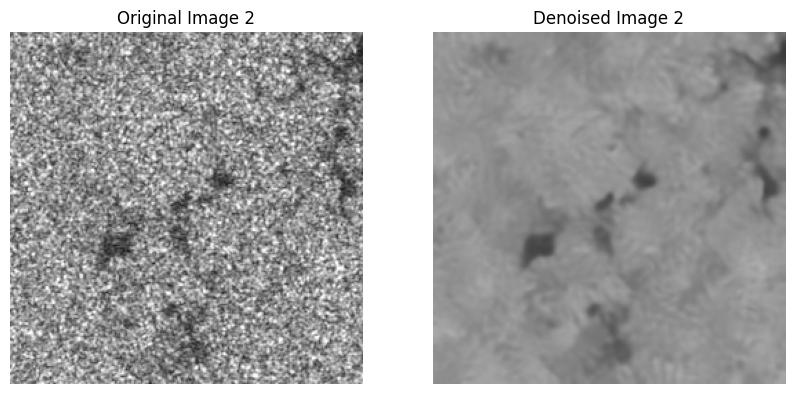

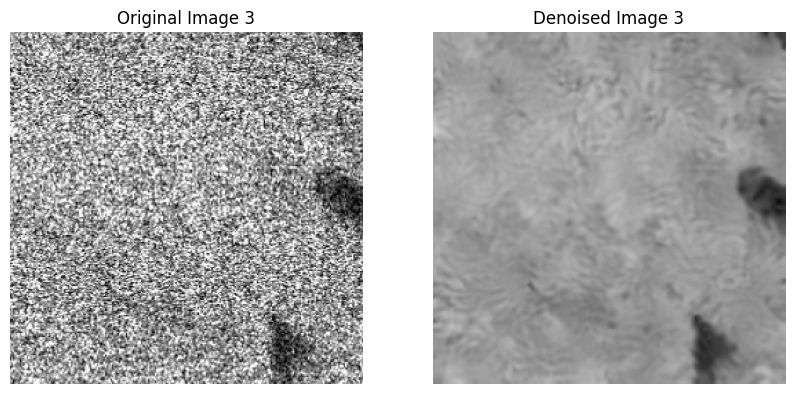

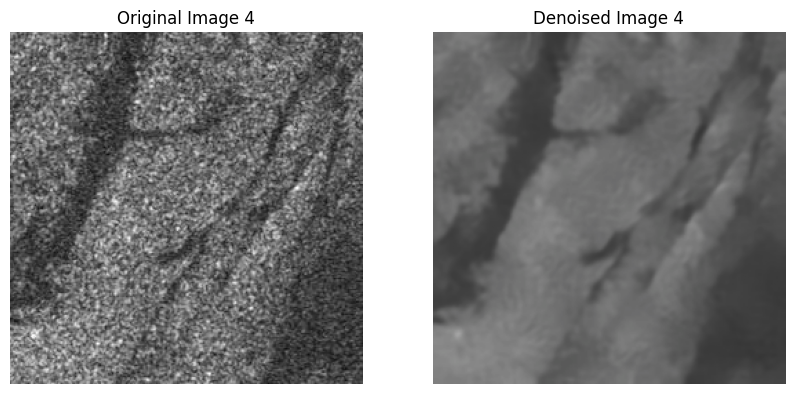

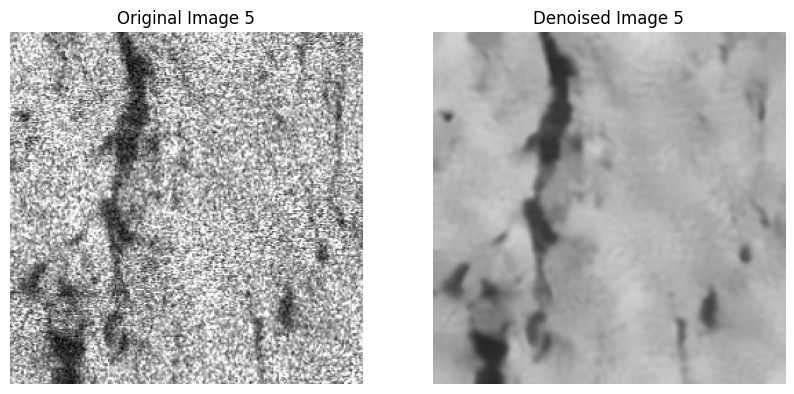

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

NORMALIZED_DIR = os.path.join(BASE_PATH, "normalize", "test", "images")
DENOISED_DIR = os.path.join(BASE_PATH, "dataset", "test", "images")


image_files = sorted([f for f in os.listdir(NORMALIZED_DIR) if f.endswith(".npy")])

print("Displaying Test original (normalized) vs. denoised images :")

for i in range(min(5, len(image_files))):
    fname = image_files[i]

    original_img_path = os.path.join(NORMALIZED_DIR, fname)
    original_img = np.load(original_img_path)

    denoised_img_path = os.path.join(DENOISED_DIR, fname)
    denoised_img = np.load(denoised_img_path)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray') # Added cmap='gray'
    plt.title(f"Original Image {i+1}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(denoised_img, cmap='gray') # Added cmap='gray'
    plt.title(f"Denoised Image {i+1}")
    plt.axis('off')

    plt.show()

# Trainig Process:

In [ ]:
!pip install segmentation-models tensorflow==2.20


In [ ]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ===== DATASET PATH =====
BASE_PATH_ROOT = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

# ===== MODEL SAVE PATH =====
MODEL_DIR = os.path.join(BASE_PATH_ROOT, "models") # Create a dedicated folder for models
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "best_oil_spill_unet.h5")

# ===== TRAINING PARAMS =====
IMG_HEIGHT = 256
IMG_WIDTH  = 256
BATCH_SIZE = 16        # 🔥 important for speed
EPOCHS = 30
LR = 1e-4

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def load_npy_safe(path):
    img = np.load(path.decode("utf-8"))

    # Remove batch dimensions
    while img.ndim > 2:
        img = img[0]

    # Now guaranteed 2D (H, W)
    return img.astype(np.float32)

In [ ]:
def load_npy_png(img_path, mask_path):
    # ---- Load image safely via NumPy ----
    img = tf.numpy_function(load_npy_safe, [img_path], tf.float32)
    img.set_shape([None, None])        # now truly 2D

    img = img[..., tf.newaxis]         # (H, W, 1)
    img = tf.image.resize(img, (IMG_HEIGHT, IMG_WIDTH))

    # Normalize
    max_val = tf.reduce_max(img)
    img = tf.where(max_val > 0, img / max_val, img)

    # ---- Load mask (.png) ----
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_HEIGHT, IMG_WIDTH))
    mask = tf.cast(mask > 0, tf.float32)

    return img, mask

In [ ]:
def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    return img, mask

In [ ]:
def build_dataset(img_dir, mask_dir, batch_size, training=True):
    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".npy")])

    img_paths = []
    mask_paths = []

    for f in img_files:
        img_path = os.path.join(img_dir, f)
        mask_name = f.replace(".npy", ".png")
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            img_paths.append(img_path)
            mask_paths.append(mask_path)
        else:
            # optional: log once if you want
            pass

    print(f"✅ Loaded {len(img_paths)} valid image-mask pairs")

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(load_npy_png, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(200)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [ ]:
train_ds = build_dataset(
    os.path.join(BASE_PATH_ROOT, "denoised", "train", "images"),
    os.path.join(BASE_PATH_ROOT, "resize", "train", "masks"),
    BATCH_SIZE,
    training=True
)

val_ds = build_dataset(
    os.path.join(BASE_PATH_ROOT, "denoised", "val", "images"),
    os.path.join(BASE_PATH_ROOT, "resize", "val", "masks"),
    BATCH_SIZE,
    training=False
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/denoised/train/images'

In [ ]:
for x, y in train_ds.take(1):
    print(x.shape, y.shape)
    print(tf.reduce_min(x).numpy(), tf.reduce_max(x).numpy())


(16, 256, 256, 1) (16, 256, 256, 1)
0.028089888 1.0


In [ ]:
def unet_model():
    inputs = layers.Input((IMG_HEIGHT, IMG_WIDTH, 1))

    # Encoder
    c1 = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(64, 3, activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(128, 3, activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation="relu", padding="same")(p2)
    c3 = layers.Conv2D(256, 3, activation="relu", padding="same")(c3)

    # Decoder
    u4 = layers.UpSampling2D()(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(128, 3, activation="relu", padding="same")(u4)

    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(64, 3, activation="relu", padding="same")(u5)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c5)

    return models.Model(inputs, outputs)

In [ ]:
def dice_coef(y_true, y_pred):
    smooth = 1.0
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

In [ ]:
model = unet_model()

model.compile(
    optimizer=Adam(LR),
    loss=dice_loss,
    metrics=[
        "accuracy",
        dice_coef,
        iou_metric,
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_9[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_11[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_13[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 128, 128,  │          0 │ conv2d_14[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 384)              │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │    442,496 │ concatenate_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 256, 256,  │          0 │ conv2d_15[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256, 256,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 192)              │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 256, 256,  │    110,656 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 256, 256,  │         65 │ conv2d_16[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,697,473 (6.48 MB)

 Trainable params: 1,697,473 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
val_ds_small = val_ds.take(30)  # ~30 batches only

history = model.fit(
    train_ds,
    validation_data=val_ds_small,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.2491 - dice_coef: 0.3951 - iou_metric: 0.2491 - loss: 0.6049 - precision_1: 0.2491 - recall_1: 1.0000
Epoch 1: val_loss improved from inf to 0.66009, saving model to /content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/best_oil_spill_unet.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 401ms/step - accuracy: 0.2495 - dice_coef: 0.3955 - iou_metric: 0.2495 - loss: 0.6045 - precision_1: 0.2495 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.2529 - dice_coef: 0.3997 - iou_metric: 0.2529 - loss: 0.6003 - precision_1: 0.2529 - recall_1: 1.0000
Epoch 2: val_loss improved from 0.66009 to 0.66008, saving model to /content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/best_oil_spill_unet.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 410ms/step - accuracy: 0.2532 - dice_coef: 0.4001 - iou_metric: 0.2532 - loss: 0.5999 - precision_1: 0.2532 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.2517 - dice_coef: 0.3988 - iou_metric: 0.2517 - loss: 0.6012 - precision_1: 0.2517 - recall_1: 1.0000
Epoch 3: val_loss improved from 0.66008 to 0.66008, saving model to /content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/best_oil_spill_unet.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 422ms/step - accuracy: 0.2520 - dice_coef: 0.3992 - iou_metric: 0.2520 - loss: 0.6008 - precision_1: 0.2520 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.2511 - dice_coef: 0.3978 - iou_metric: 0.2511 - loss: 0.6022 - precision_1: 0.2511 - recall_1: 1.0000
Epoch 4: val_loss improved from 0.66008 to 0.66008, saving model to /content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/best_oil_spill_unet.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 422ms/step - accuracy: 0.2515 - dice_coef: 0.3982 - iou_metric: 0.2515 - loss: 0.6018 - precision_1: 0.2515 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.2519 - dice_coef: 0.3991 - iou_metric: 0.2519 - loss: 0.6009 - precision_1: 0.2519 - recall_1: 1.0000
Epoch 5: val_loss improved from 0.66008 to 0.66008, saving model to /content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/best_oil_spill_unet.h5


...

131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 426ms/step - accuracy: 0.2492 - dice_coef: 0.3951 - iou_metric: 0.2492 - loss: 0.6049 - precision_1: 0.2492 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.2520 - dice_coef: 0.3994 - iou_metric: 0.2520 - loss: 0.6006 - precision_1: 0.2520 - recall_1: 1.0000
Epoch 8: val_loss improved from 0.66008 to 0.66008, saving model to /content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/best_oil_spill_unet.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 421ms/step - accuracy: 0.2523 - dice_coef: 0.3998 - iou_metric: 0.2523 - loss: 0.6002 - precision_1: 0.2523 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 9/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.2502 - dice_coef: 0.3966 - iou_metric: 0.2502 - loss: 0.6034 - precision_1: 0.2502 - recall_1: 1.0000
Epoch 9: val_loss improved from 0.66008 to 0.66008, saving model to /content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/best_oil_spill_unet.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 422ms/step - accuracy: 0.2505 - dice_coef: 0.3970 - iou_metric: 0.2505 - loss: 0.6030 - precision_1: 0.2505 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 10/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.2525 - dice_coef: 0.4003 - iou_metric: 0.2525 - loss: 0.5997 - precision_1: 0.2525 - recall_1: 1.0000
Epoch 10: val_loss improved from 0.66008 to 0.66008, saving model to /content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/best_oil_spill_unet.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 425ms/step - accuracy: 0.2529 - dice_coef: 0.4007 - iou_metric: 0.2529 - loss: 0.5993 - precision_1: 0.2529 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 11/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.2503 - dice_coef: 0.3967 - iou_metric: 0.2503 - loss: 0.6033 - precision_1: 0.2503 - recall_1: 1.0000
Epoch 11: val_loss did not improve from 0.66008
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 413ms/step - accuracy: 0.2507 - dice_coef: 0.3971 - iou_metric: 0.2507 - loss: 0.6029 - precision_1: 0.2507 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 12/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.2523 - dice_coef: 0.3997 - iou_metric: 0.2523 - loss: 0.6004 - precision_1: 0.2523 - recall_1: 1.0000
Epoch 12: 

131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 422ms/step - accuracy: 0.2512 - dice_coef: 0.3980 - iou_metric: 0.2512 - loss: 0.6020 - precision_1: 0.2512 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 15/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.2519 - dice_coef: 0.3990 - iou_metric: 0.2519 - loss: 0.6010 - precision_1: 0.2519 - recall_1: 1.0000
Epoch 15: val_loss did not improve from 0.66008
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 417ms/step - accuracy: 0.2522 - dice_coef: 0.3994 - iou_metric: 0.2522 - loss: 0.6006 - precision_1: 0.2522 - recall_1: 1.0000 - val_accuracy: 0.2086 - val_dice_coef: 0.3399 - val_iou_metric: 0.2086 - val_loss: 0.6601 - val_precision_1: 0.2086 - val_recall_1: 1.0000
Epoch 16/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.2498 - dice_coef: 0.3962 - iou_metric: 0.2498 - loss: 0.6038 - precision_1: 0.2498 - recall_1: 1.0000
Epoch 16: 

# Model Test :

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
BASE_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/dataset/test"

IMG_DIR  = os.path.join(BASE_PATH, "images")   # .npy files
MASK_DIR = os.path.join(BASE_PATH, "masks")    # .png / .jpg masks

MODEL_PATH = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring/models/best_unet.keras"

IMG_SIZE  = 256      # must match training
THRESHOLD = 0.5

In [ ]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ Model loaded successfully")

model.input_shape

✅ Model loaded successfully


(None, 256, 256, 1)

In [ ]:
def load_image_npy(path):
    img = np.load(path).astype(np.float32)   # (256,256,3)

    # ✅ Convert 3-channel → 1-channel (MATCHES MODEL)
    img = img.mean(axis=-1)                  # (256,256)

    # ✅ Normalize to [0,1]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # ✅ Resize (safe even if already 256×256)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # ✅ Add channel dimension → (256,256,1)
    img = img[..., np.newaxis]

    return img

In [ ]:
def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise RuntimeError(f"❌ Cannot read mask: {path}")

    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = (mask > 127).astype(np.uint8)

    return mask

In [ ]:
def get_mask_name(npy_name):
    base = os.path.splitext(npy_name)[0]
    return base + ".png"   # change to .jpg if needed

In [ ]:
image_files = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.endswith(".npy")
])

print(f"✅ Found {len(image_files)} test images")

✅ Found 787 test images



📂 File: palsar_0.npy
Shape: (256, 256, 3)
Dtype: float32
Min: 0.14117648 Max: 0.78431374 Mean: 0.6015213


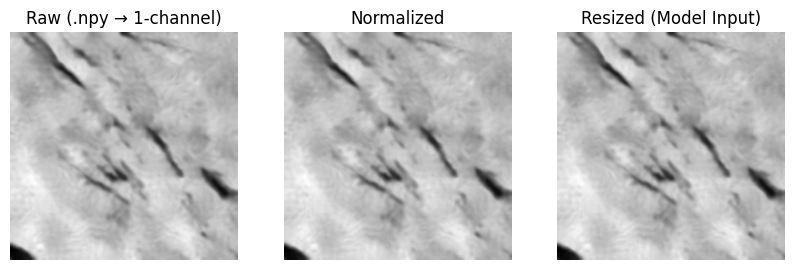


📂 File: palsar_1001.npy
Shape: (256, 256, 3)
Dtype: float32
Min: 0.22745098 Max: 0.68235296 Mean: 0.5544612


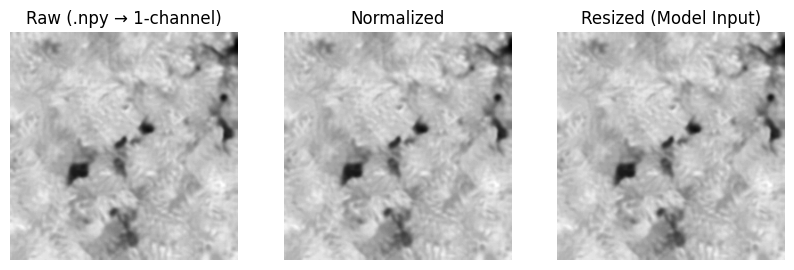


📂 File: palsar_1002.npy
Shape: (256, 256, 3)
Dtype: float32
Min: 0.05490196 Max: 0.80784315 Mean: 0.5905134


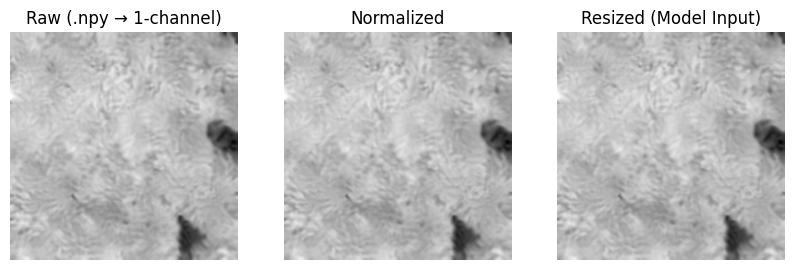


📂 File: palsar_1010.npy
Shape: (256, 256, 3)
Dtype: float32
Min: 0.20784314 Max: 0.6431373 Mean: 0.38191414


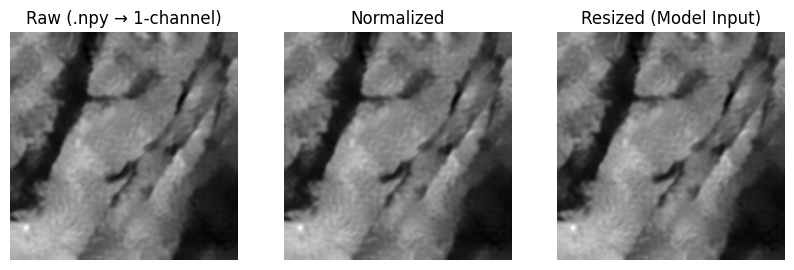


📂 File: palsar_1020.npy
Shape: (256, 256, 3)
Dtype: float32
Min: 0.15294118 Max: 0.85490197 Mean: 0.6442413


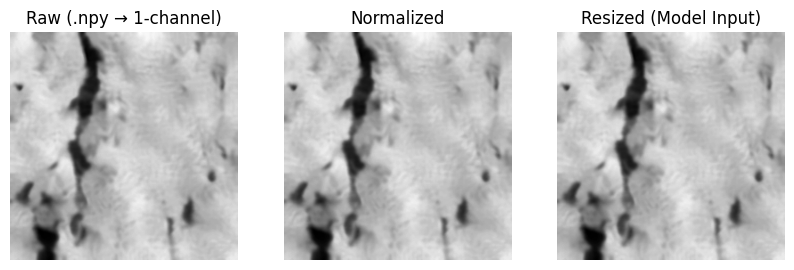

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

NUM_SAMPLES = 5

npy_files = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.endswith(".npy")
])[:NUM_SAMPLES]

for file in npy_files:
    path = os.path.join(IMG_DIR, file)

    img = np.load(path).astype(np.float32)

    print(f"\n📂 File: {file}")
    print("Shape:", img.shape)
    print("Dtype:", img.dtype)
    print("Min:", img.min(), "Max:", img.max(), "Mean:", img.mean())

    # 🔑 Convert 3-channel → 1-channel (SAME AS MODEL)
    if img.ndim == 3:
        img = img.mean(axis=-1)

    # Normalize for visualization
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

    img_resized = cv2.resize(img_norm, (256, 256))

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap="gray")
    plt.title("Raw (.npy → 1-channel)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(img_norm, cmap="gray")
    plt.title("Normalized")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(img_resized, cmap="gray")
    plt.title("Resized (Model Input)")
    plt.axis("off")

    plt.show()

In [ ]:
TP = FP = FN = TN = 0

In [ ]:
for file in tqdm(image_files):
    img_path  = os.path.join(IMG_DIR, file)
    mask_path = os.path.join(MASK_DIR, get_mask_name(file))

    if not os.path.exists(mask_path):
        print(f"⚠ Missing mask for {file}")
        continue

    image = load_image_npy(img_path)
    mask  = load_mask(mask_path)

    pred = model.predict(image[np.newaxis, ...], verbose=0)[0]
    pred = (pred.squeeze() > THRESHOLD).astype(np.uint8)

    pred_f = pred.flatten()
    mask_f = mask.flatten()

    TP += ((pred_f == 1) & (mask_f == 1)).sum()
    FP += ((pred_f == 1) & (mask_f == 0)).sum()
    FN += ((pred_f == 0) & (mask_f == 1)).sum()
    TN += ((pred_f == 0) & (mask_f == 0)).sum()

100%|██████████| 787/787 [01:17<00:00, 10.15it/s]


In [ ]:
eps = 1e-7

precision = TP / (TP + FP + eps)
recall    = TP / (TP + FN + eps)
f1_score  = 2 * precision * recall / (precision + recall + eps)
iou       = TP / (TP + FP + FN + eps)
dice      = 2 * TP / (2 * TP + FP + FN + eps)

print("\n📊 FINAL TEST METRICS (NUMERICAL)")
print(f"Dice Coefficient : {dice:.4f}")
print(f"IoU              : {iou:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1_score:.4f}")

print("\n📌 CONFUSION MATRIX VALUES")
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")


📊 FINAL TEST METRICS (NUMERICAL)
Dice Coefficient : 0.4023
IoU              : 0.2518
Precision        : 0.2518
Recall           : 1.0000
F1-Score         : 0.4023

📌 CONFUSION MATRIX VALUES
TP: 12986223
FP: 38590609
FN: 0
TN: 0


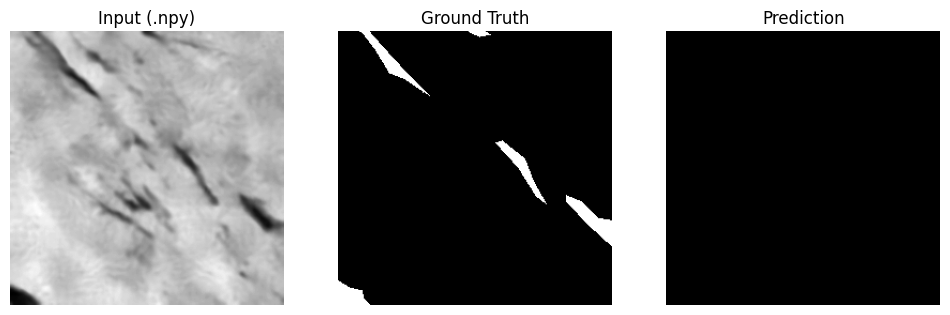

In [ ]:
sample = image_files[0]

img  = load_image_npy(os.path.join(IMG_DIR, sample)).squeeze()
mask = load_mask(os.path.join(MASK_DIR, get_mask_name(sample)))

pred = model.predict(img[np.newaxis, ..., np.newaxis], verbose=0)[0]
pred = (pred.squeeze() > THRESHOLD)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Input (.npy)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()

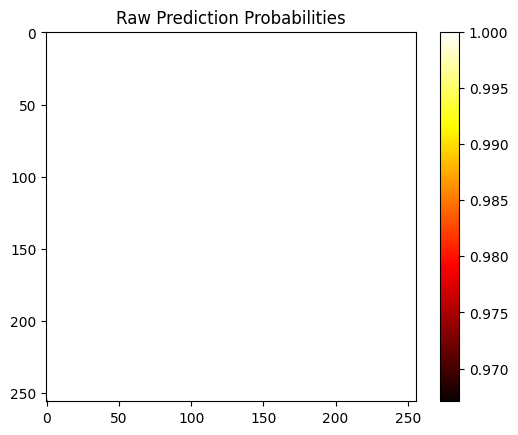

In [ ]:
pred_raw = model.predict(img[np.newaxis, ..., np.newaxis], verbose=0)[0]

plt.imshow(pred_raw.squeeze(), cmap="hot")
plt.colorbar()
plt.title("Raw Prediction Probabilities")
plt.show()

In [ ]:
# pred_raw already computed above
# mask already loaded above

mask_f = mask.flatten()

print("\n🔍 Threshold vs Dice (single image)")

for t in [0.3, 0.5, 0.7, 0.8, 0.9]:
    pred = (pred_raw.squeeze() > t).astype(np.uint8)

    pred_f = pred.flatten()

    TP = ((pred_f == 1) & (mask_f == 1)).sum()
    FP = ((pred_f == 1) & (mask_f == 0)).sum()
    FN = ((pred_f == 0) & (mask_f == 1)).sum()

    dice = (2 * TP) / (2 * TP + FP + FN + 1e-7)

    print(f"Threshold {t:.1f} → Dice: {dice:.4f}")



🔍 Threshold vs Dice (single image)
Threshold 0.3 → Dice: 0.0670
Threshold 0.5 → Dice: 0.0670
Threshold 0.7 → Dice: 0.0670
Threshold 0.8 → Dice: 0.0670
Threshold 0.9 → Dice: 0.0670


# Re training 1:

In [ ]:
import tensorflow as tf

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("✅ Mixed precision enabled")

✅ Mixed precision enabled


In [ ]:
import os, cv2, numpy as np
from tqdm import tqdm


In [ ]:
# step 1
BASE = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

TRAIN_IMG_DIR = f"{BASE}/dataset/train/images"
TRAIN_MASK_DIR = f"{BASE}/dataset/train/masks"
VAL_IMG_DIR   = f"{BASE}/dataset/val/images"
VAL_MASK_DIR  = f"{BASE}/dataset/val/masks"

SAVE_PATH = f"{BASE}/models/unet_industry_gpu_4h.keras"

IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 12
LR = 1e-4

In [ ]:
# step 2
def load_image_npy(path):
    img = np.load(path).astype(np.float32)
    img = img.mean(axis=-1)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img[..., np.newaxis]

def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.float32)
    return mask[..., np.newaxis]

In [ ]:
#SANITY CHECK (RUN ONCE, 1 IMAGE)
sample_img_name = os.listdir(TRAIN_IMG_DIR)[0]

img = load_image_npy(os.path.join(TRAIN_IMG_DIR, sample_img_name))
mask = load_mask(os.path.join(TRAIN_MASK_DIR, sample_img_name.replace(".npy",".png")))

print("Image shape:", img.shape)
print("Mask shape :", mask.shape)
print("Image min/max:", img.min(), img.max())
print("Mask unique:", np.unique(mask))

Image shape: (256, 256, 1)
Mask shape : (256, 256, 1)
Image min/max: 0.0 1.0
Mask unique: [0. 1.]


In [ ]:
# step 3
def data_generator(img_dir, mask_dir, batch_size):
    files = [f for f in os.listdir(img_dir) if f.endswith(".npy")]

    while True:
        np.random.shuffle(files)
        for i in range(0, len(files), batch_size):
            X, Y = [], []
            for f in files[i:i+batch_size]:
                mp = os.path.join(mask_dir, f.replace(".npy", ".png"))
                if not os.path.exists(mp): continue
                X.append(load_image_npy(os.path.join(img_dir, f)))
                Y.append(load_mask(mp))
            yield np.array(X), np.array(Y)

In [ ]:
#Step 4
def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-4, 1 - 1e-4)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    return 1 - (2. * intersection + 1e-6) / (union + 1e-6)

bce = tf.keras.losses.BinaryCrossentropy()

def combined_loss(y_true, y_pred):
    return 0.9 * bce(y_true, y_pred) + 0.1 * dice_loss(y_true, y_pred)


In [ ]:
# step 5
model = tf.keras.models.load_model(
    f"{BASE}/models/unet_balanced_debug.keras",
    compile=False
)

In [ ]:
# step 6
opt = tf.keras.optimizers.Adam(LR)
model.compile(optimizer=opt, loss=combined_loss)

In [ ]:
# step 7
class PredictionMonitor(tf.keras.callbacks.Callback):
    def __init__(self, sample):
        self.sample = sample

    def on_epoch_end(self, epoch, logs=None):
        p = self.model.predict(self.sample[np.newaxis,...], verbose=0)[0]
        print(f"Epoch {epoch+1} → pred mean = {p.mean():.4f}")

In [ ]:
sample_img = load_image_npy(
    os.path.join(TRAIN_IMG_DIR, os.listdir(TRAIN_IMG_DIR)[0])
)

In [ ]:
# step 8
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
# step 9
train_gen = data_generator(TRAIN_IMG_DIR, TRAIN_MASK_DIR, BATCH_SIZE)
val_gen   = data_generator(VAL_IMG_DIR, VAL_MASK_DIR, BATCH_SIZE)

model.fit(
    train_gen,
    steps_per_epoch=100,
    validation_data=val_gen,
    validation_steps=25,
    epochs=EPOCHS,
    callbacks=[PredictionMonitor(sample_img), early_stop]
)


Epoch 1/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 0.2707Epoch 1 → pred mean = 0.2733
100/100 ━━━━━━━━━━━━━━━━━━━━ 898s 9s/step - loss: 0.2707 - val_loss: 0.2363
Epoch 2/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 0.2690Epoch 2 → pred mean = 0.3205
100/100 ━━━━━━━━━━━━━━━━━━━━ 736s 7s/step - loss: 0.2690 - val_loss: 0.2599
Epoch 3/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 0.2523Epoch 3 → pred mean = 0.2552
100/100 ━━━━━━━━━━━━━━━━━━━━ 728s 7s/step - loss: 0.2524 - val_loss: 0.2593
Epoch 4/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - loss: 0.2698Epoch 4 → pred mean = 0.3074
100/100 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - loss: 0.2697 - val_loss: 0.2883


In [ ]:
model.save(SAVE_PATH)
print("✅ GPU-trained industry model saved")

✅ GPU-trained industry model saved


# Evaluation 1

In [ ]:
import os, cv2, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
BASE = "/content/drive/MyDrive/AI-Driven System for Oil Spill Identification and Monitoring"

TEST_IMG_DIR  = f"{BASE}/dataset/test/images"
TEST_MASK_DIR = f"{BASE}/dataset/test/masks"

MODEL_PATH = f"{BASE}/models/unet_industry_gpu_4h.keras"

IMG_SIZE = 256
THRESHOLD = 0.4
MIN_AREA = 500

In [ ]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ Model loaded for evaluation")

✅ Model loaded for evaluation


In [ ]:
# step 2
def load_image_npy(path):
    img = np.load(path).astype(np.float32)
    img = img.mean(axis=-1)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img[..., np.newaxis]

def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.uint8)
    return mask


In [ ]:
# step 3
def remove_small_components(mask, min_area=500):
    mask = (mask * 255).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    out = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels == i] = 255
    return (out > 0).astype(np.uint8)


In [ ]:
# step 4
TP = FP = FN = TN = 0

files = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".npy")]

for f in tqdm(files):
    img_path  = os.path.join(TEST_IMG_DIR, f)
    mask_path = os.path.join(TEST_MASK_DIR, f.replace(".npy", ".png"))
    if not os.path.exists(mask_path):
        continue

    img  = load_image_npy(img_path)
    mask = load_mask(mask_path)

    pred = model.predict(img[np.newaxis,...], verbose=0)[0].squeeze()
    pred = (pred > THRESHOLD).astype(np.uint8)
    pred = remove_small_components(pred, MIN_AREA)

    p = pred.flatten()
    m = mask.flatten()

    TP += ((p==1)&(m==1)).sum()
    FP += ((p==1)&(m==0)).sum()
    FN += ((p==0)&(m==1)).sum()
    TN += ((p==0)&(m==0)).sum()


100%|██████████| 787/787 [07:44<00:00,  1.69it/s]


In [ ]:
# step 5
eps = 1e-7

precision = TP / (TP + FP + eps)
recall    = TP / (TP + FN + eps)
f1        = 2 * precision * recall / (precision + recall + eps)
iou       = TP / (TP + FP + FN + eps)
dice      = 2 * TP / (2 * TP + FP + FN + eps)

print("\n📊 FINAL TEST METRICS")
print(f"Dice Coefficient : {dice:.4f}")
print(f"IoU              : {iou:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")

print("\n📌 CONFUSION MATRIX")
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")



📊 FINAL TEST METRICS
Dice Coefficient : 0.7637
IoU              : 0.6177
Precision        : 0.7060
Recall           : 0.8316
F1-Score         : 0.7637

📌 CONFUSION MATRIX
TP: 10798702
FP: 4496548
FN: 2187521
TN: 34094061


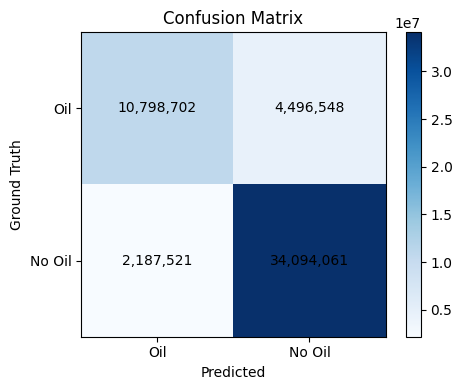

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix array
cm = np.array([
    [TP, FP],
    [FN, TN]
])

labels = ["Oil", "No Oil"]

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")

# Write numbers inside cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]:,}",
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

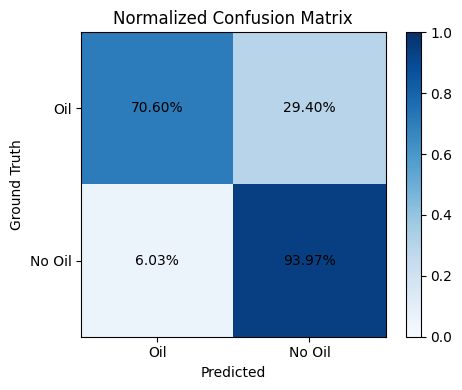

In [ ]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Normalized Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm_norm[i, j]*100:.2f}%",
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


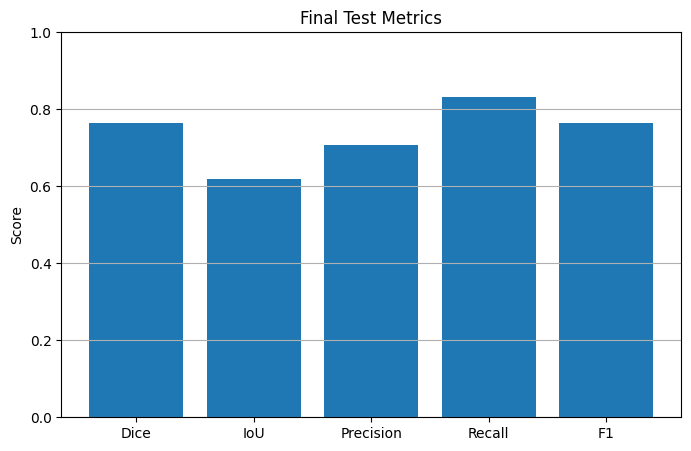

In [ ]:
#
metrics = {
    "Dice": dice,
    "IoU": iou,
    "Precision": precision,
    "Recall": recall,
    "F1": f1
}

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0,1)
plt.title("Final Test Metrics")
plt.ylabel("Score")
plt.grid(axis="y")
plt.show()


In [ ]:
def visualize_sample_with_explanation(fname):
    img  = load_image_npy(os.path.join(TEST_IMG_DIR, fname))
    mask = load_mask(os.path.join(TEST_MASK_DIR, fname.replace(".npy",".png")))

    # Raw probability (no threshold)
    prob = model.predict(img[np.newaxis,...], verbose=0)[0].squeeze()

    # Final binary prediction
    pred = (prob > THRESHOLD).astype(np.uint8)
    pred = remove_small_components(pred, MIN_AREA)

    plt.figure(figsize=(18,4))

    # Input
    plt.subplot(1,4,1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title("Input (SAR)")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,4,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth\n(White = Oil, Black = Background)")
    plt.axis("off")

    # Raw Probability Map
    plt.subplot(1,4,3)
    im = plt.imshow(prob, cmap="jet", vmin=0, vmax=1)
    plt.title("Raw Probability Map\nBlue=No Oil, Yellow=Uncertain, Red=Oil")
    plt.axis("off")
    cbar = plt.colorbar(im, fraction=0.046)
    cbar.set_label("Oil Probability", rotation=270, labelpad=15)

    # Final Prediction
    plt.subplot(1,4,4)
    plt.imshow(pred, cmap="gray")
    plt.title(f"Prediction (t={THRESHOLD})\nWhite=Oil")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

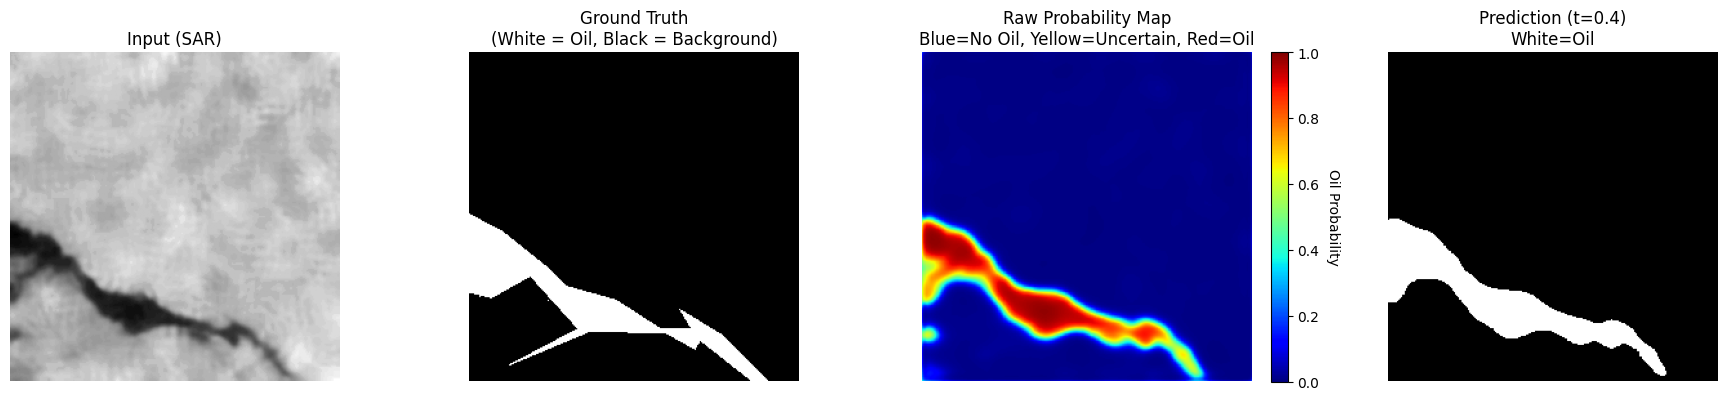

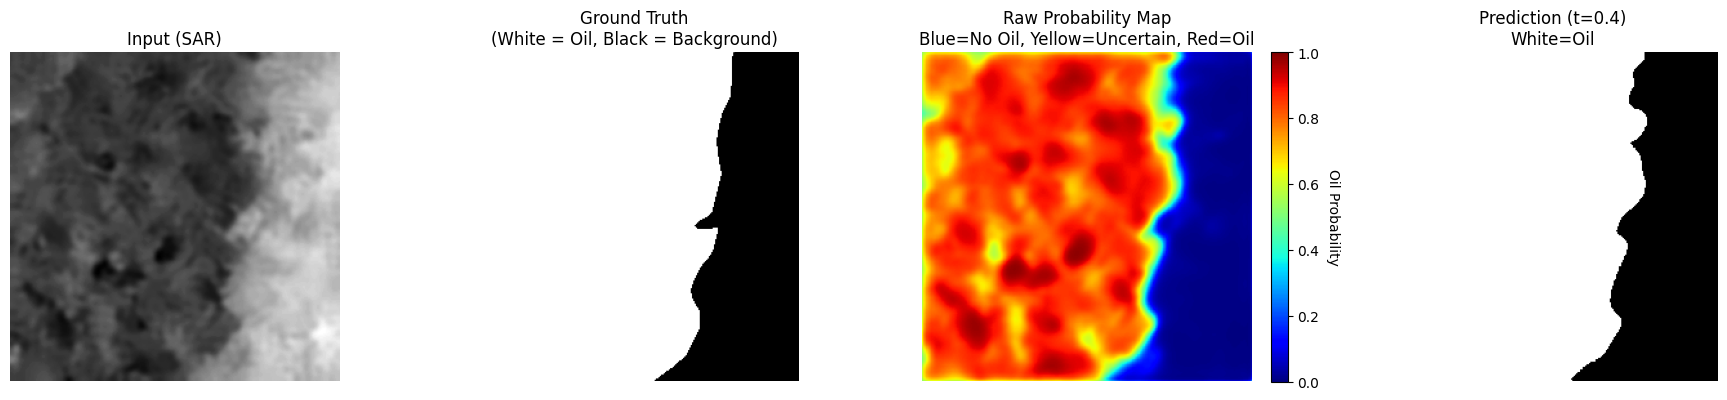

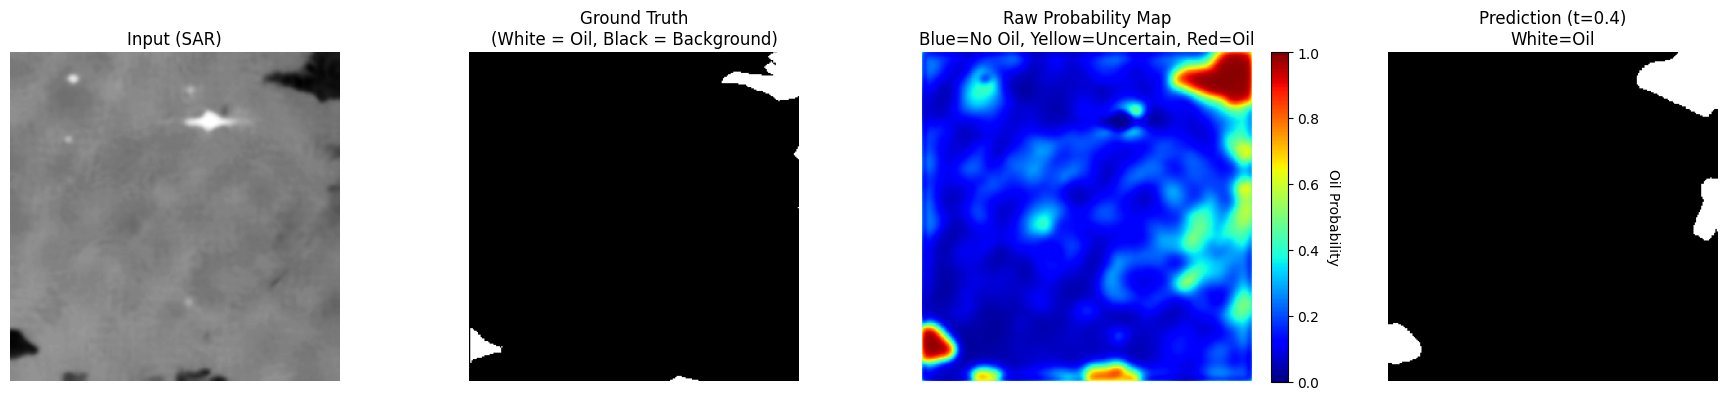

In [ ]:
for f in np.random.choice(files, 3, replace=False):
    visualize_sample_with_explanation(f)